In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import seaborn as sns

### Data Loading

In [5]:

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

### Exploratory Data Analysis

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


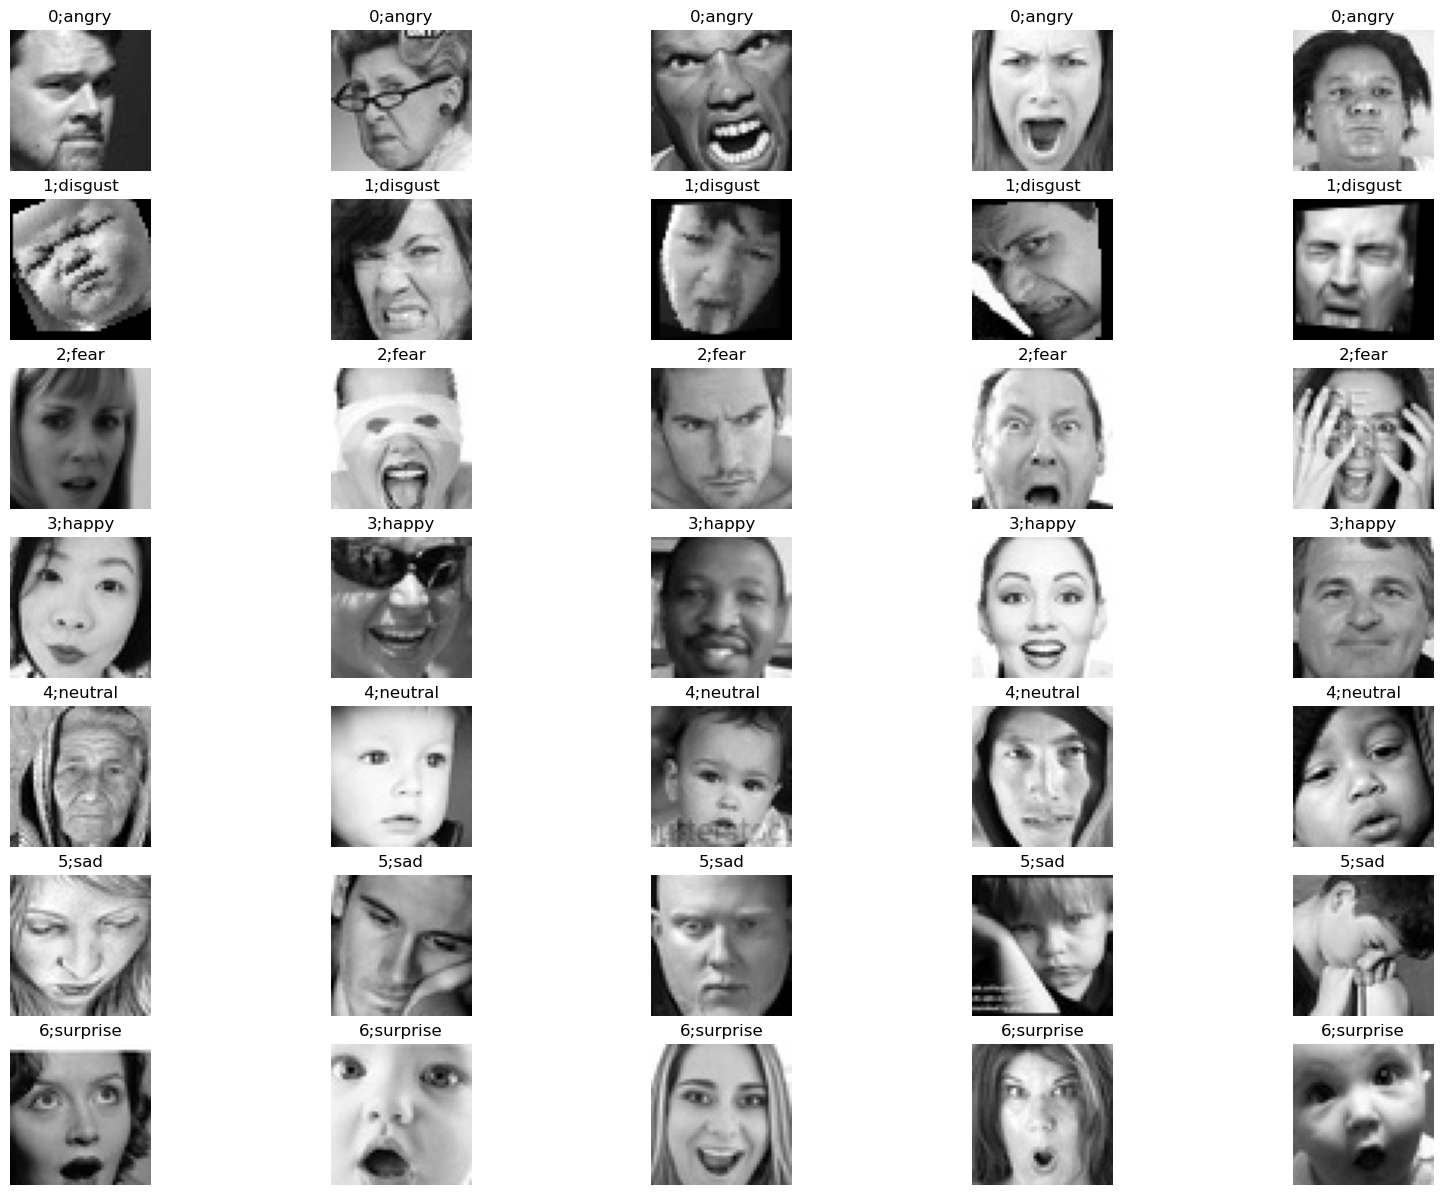

In [13]:
class_names = train_dataset.classes
print("Classes:", class_names)

def plot_images(dataset, num_images=5):
    dataloader = DataLoader(dataset,batch_size=1000,shuffle=True)
    class_names = train_dataset.classes
    fig, axes = plt.subplots(len(class_names),num_images, figsize=(20,15))
    images, labels = next(iter(dataloader))
    for i in range(len(class_names)):
        tmp = images[labels==i]
        for j in range(num_images):
            image = tmp[j]
            label = i
            axes[i,j].imshow(image.squeeze(), cmap="gray")
            axes[i,j].set_title(f"{label};{class_names[label]}")
            axes[i,j].axis("off")
    plt.show()

plot_images(train_dataset)

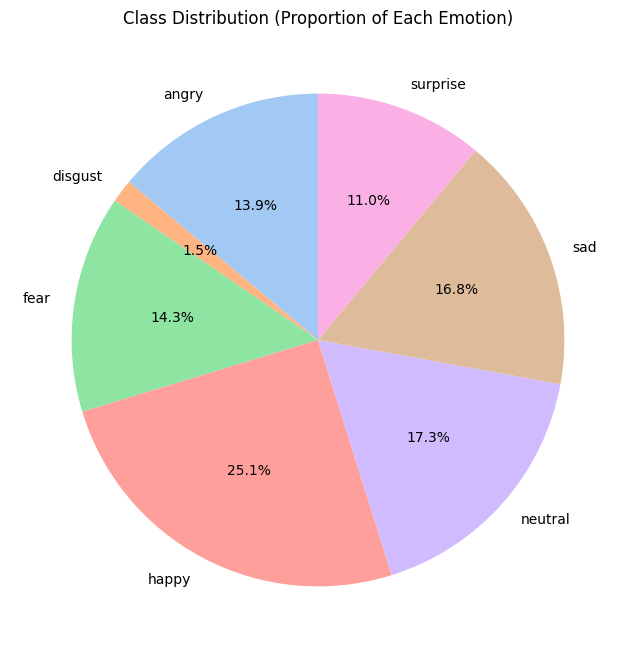

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Class Distribution (Proportion of Each Emotion)")
plt.show()

In [ ]:
mean_count = np.mean(counts)
median_count = np.median(counts)
std_count = np.std(counts)

print(f"Mean count of samples per class: {mean_count:.2f}")
print(f"Median count of samples per class: {median_count:.2f}")
print(f"Standard deviation of samples per class: {std_count:.2f}")

Mean count of samples per class: 4101.29
Median count of samples per class: 4097.00
Standard deviation of samples per class: 1900.50


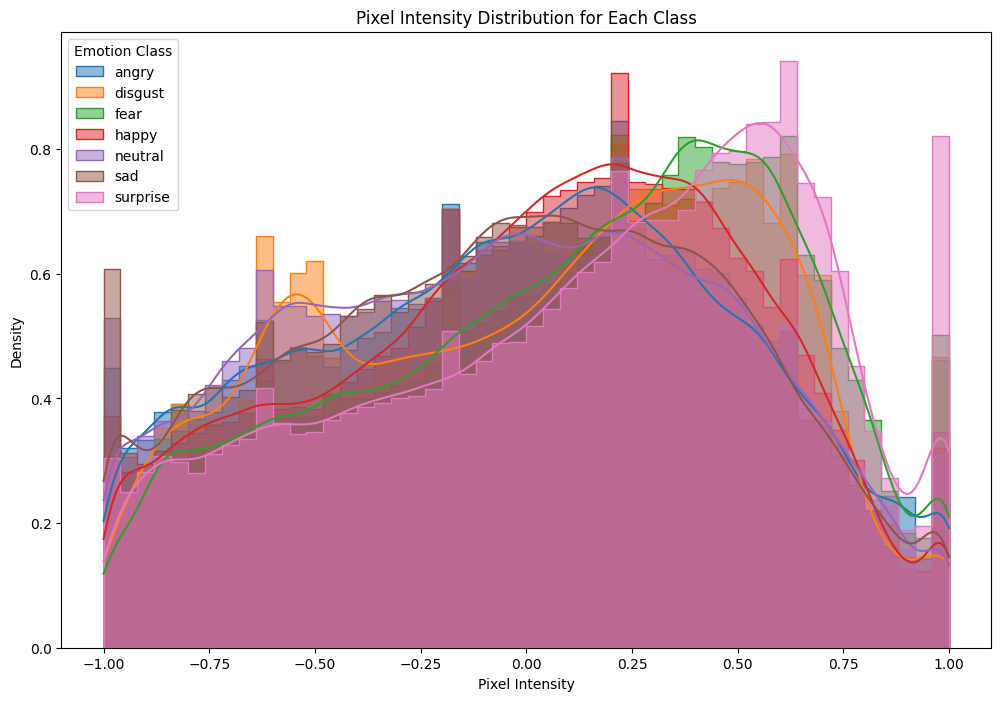

In [ ]:
def plot_intensity_distribution(dataset):
    dataloader = DataLoader(dataset, batch_size=1000, shuffle=True)
    images, labels = next(iter(dataloader))
    images = images.numpy().squeeze()
    
    plt.figure(figsize=(12, 8))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == i]
        pixel_values = class_images.flatten()
        sns.histplot(pixel_values, kde=True, bins=50, label=class_name, element="step", stat="density")
    
    plt.title("Pixel Intensity Distribution for Each Class")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend(title="Emotion Class")
    plt.show()

plot_intensity_distribution(train_dataset)

BASELINE Without Augmentation

In [6]:
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [7]:
# Flatten images and extract labels
def preprocess_data(loader):
    images, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.view(imgs.size(0), -1).numpy()  # Flatten images
        images.extend(imgs)
        labels.extend(lbls.numpy())
    return np.array(images), np.array(labels)

In [8]:
# Preprocess train and test data
train_images, train_labels = preprocess_data(train_loader)
test_images, test_labels = preprocess_data(test_loader)

In [9]:
# Split training data for validation
X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

In [10]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [11]:
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# Validate the model
y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 43.85%


In [13]:
# Test the model
y_test_pred = rf_model.predict(test_images)
test_accuracy = accuracy_score(test_labels, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 44.87%


In [14]:
# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, y_test_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

       angry       0.41      0.20      0.27       958
     disgust       1.00      0.28      0.44       111
        fear       0.46      0.24      0.31      1024
       happy       0.44      0.77      0.56      1774
     neutral       0.40      0.39      0.40      1233
         sad       0.37      0.34      0.35      1247
    surprise       0.67      0.58      0.62       831

    accuracy                           0.45      7178
   macro avg       0.54      0.40      0.42      7178
weighted avg       0.46      0.45      0.43      7178



AUGMENTATION

In [ ]:
import os
from torchvision.transforms import functional as F
from torchvision.utils import save_image


augmentation = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5)
])

disgust_class_path = os.path.join(train_dir, "disgust")
disgust_images = [os.path.join(disgust_class_path, img) for img in os.listdir(disgust_class_path)]

target_count = 2000
current_count = len(disgust_images)
augment_count = max(0, target_count - current_count)

print(f"Generating {augment_count} augmented images for the 'disgust' class...")

for i in range(augment_count):
    img_path = np.random.choice(disgust_images)
    img = plt.imread(img_path)
    img = torch.tensor(img).unsqueeze(0).float() / 255.0
    
    augmented_img = augmentation(img)
    
    aug_img_path = os.path.join(disgust_class_path, f"augmented_{i}.png")
    save_image(augmented_img, aug_img_path)

print(f"Augmentation complete. Augmented images saved to '{disgust_class_path}'.")

Generating 1564 augmented images for the 'disgust' class...
Augmentation complete. Augmented images saved to 'FER2013/Train\disgust'.


In [2]:

train_dir = "FER2013/Train"
test_dir = "FER2013/Test"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

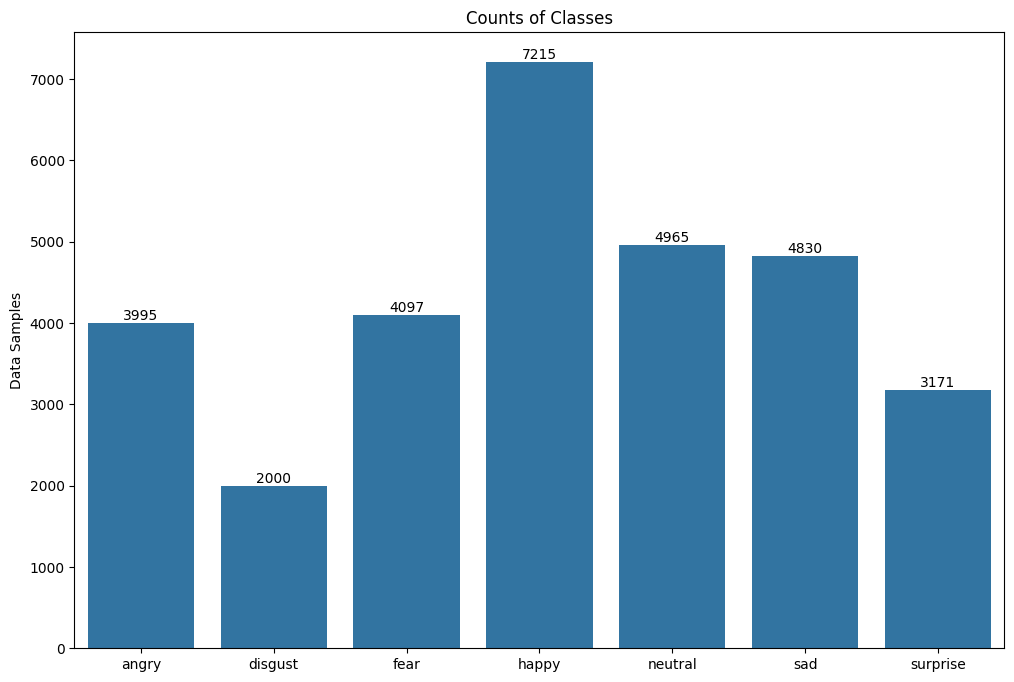

In [26]:
labels = [label for _,label in train_dataset]
labels = np.array(labels)
classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12,8))
ax = sns.barplot(y = counts, x = class_names)
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

plt.ylabel("Data Samples")
plt.title("Counts of Classes")
plt.show()

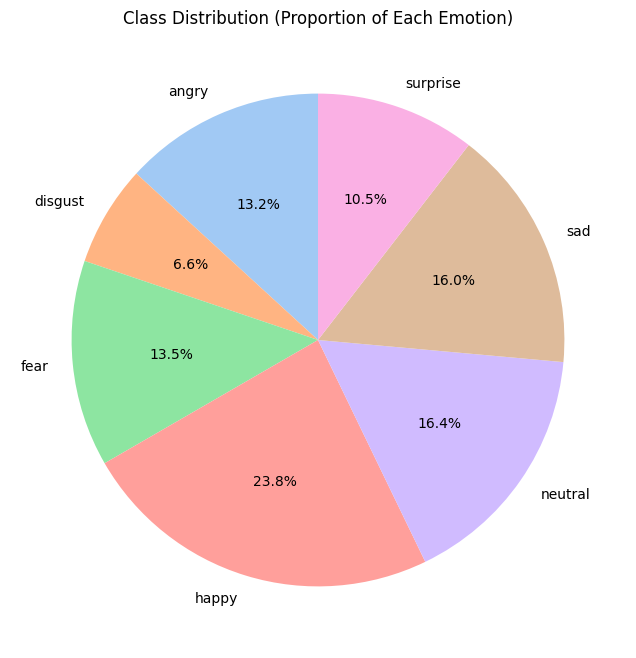

In [27]:
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Class Distribution (Proportion of Each Emotion)")
plt.show()

BASELINE WITH AUGMENTATION

In [ ]:

def preprocess_data(loader):
    images, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.view(imgs.size(0), -1).numpy()
        images.extend(imgs)
        labels.extend(lbls.numpy())
    return np.array(images), np.array(labels)


In [ ]:

train_images, train_labels = preprocess_data(train_loader)
test_images, test_labels = preprocess_data(test_loader)

In [ ]:

X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

In [ ]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:

y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 47.46%


In [ ]:

y_test_pred = rf_model.predict(test_images)
test_accuracy = accuracy_score(test_labels, y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 44.43%


In [ ]:

print("\nClassification Report:")
print(classification_report(test_labels, y_test_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.20      0.27       958
     disgust       0.60      0.23      0.34       111
        fear       0.44      0.26      0.33      1024
       happy       0.44      0.76      0.56      1774
     neutral       0.39      0.38      0.38      1233
         sad       0.38      0.33      0.35      1247
    surprise       0.66      0.57      0.62       831

    accuracy                           0.44      7178
   macro avg       0.48      0.39      0.41      7178
weighted avg       0.45      0.44      0.42      7178



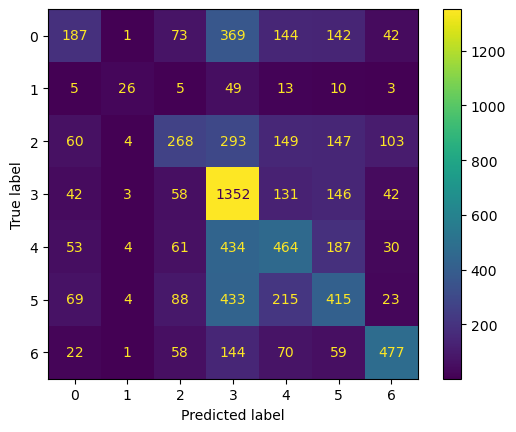

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(test_labels, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1, 2, 3, 4, 5, 6])
cm_display.plot()
plt.show()